# EDA — Retards TGV SNCF

Exploration des données SNCF Open Data pour comprendre la distribution des retards, les tendances temporelles, et identifier les features pertinentes pour la modélisation.

In [2]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = pathlib.Path("../sncf_retards.csv")
COL_DEPART  = "Gare de départ"
COL_ARRIVEE = "Gare d'arrivée"
TARGET = "Retard moyen de tous les trains à l'arrivée"


## 1. Chargement et inspection

In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

# Supprimer colonnes de commentaires (100% nulles) et Service (valeur unique "National")
cols_drop = [c for c in df.columns if "Commentaire" in c] + ["Service"]
df = df.drop(columns=cols_drop)

print(f"Shape : {df.shape}")
df.head()


Shape : (12181, 22)


,Date,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,289,11.247809,3.693179,147,28.436735,6.511118,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,LE MANS,PARIS MONTPARNASSE,56,406,1,213,8.479969,4.567119,105,18.049048,5.363539,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,21,6.239683,0.286283,19,24.736842,2.938053,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,PARIS MONTPARNASSE,NANTES,124,508,3,71,7.235211,0.734290,58,33.726437,5.292211,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,POITIERS,PARIS MONTPARNASSE,94,472,4,224,6.784673,3.229701,89,14.592697,4.882372,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12181 entries, 0 to 12180
Data columns (total 22 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12181 non-null  object 
 1   Gare de départ                                                                               12181 non-null  object 
 2   Gare d'arrivée                                                                               12181 non-null  object 
 3   Durée moyenne du trajet                                                                      12181 non-null  int64  
 4   Nombre de circulations prévues                                                               12181 non-null  int64  
 5   Nombre de trains annulés        

In [5]:
# Statistiques descriptives — colonnes numériques uniquement
df.select_dtypes(include="number").describe()


,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
count,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000,12181.000000
mean,170.530663,271.908628,8.518102,85.983335,12.342160,3.129790,37.720466,35.210768,6.083299,27.087842,36.329792,12.688942,5.198424,21.754982,21.765944,20.423789,18.881992,7.388447,7.576489
std,87.715225,183.053910,22.352206,88.392842,11.704363,5.097070,31.428906,15.551285,6.939533,22.855195,19.392901,12.251177,5.992260,16.013291,14.874187,14.598588,13.490876,8.076885,9.478385
min,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-472.638889,0.000000,-4.000000,-44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,151.000000,0.000000,21.000000,6.235190,1.206921,15.000000,25.812346,3.407806,11.000000,28.254023,4.000000,1.000000,10.526316,11.764706,10.526316,10.000000,0.000000,0.000000
50%,163.000000,230.000000,2.000000,52.000000,10.423055,2.325148,30.000000,33.503509,5.377829,22.000000,37.697619,9.000000,3.000000,19.444444,20.000000,18.750000,17.021277,5.882353,5.000000
75%,223.000000,360.000000,7.000000,126.000000,15.816319,3.958105,51.000000,42.457576,8.126984,37.000000,47.010648,18.000000,7.000000,30.000000,29.411765,28.571429,25.373134,11.111111,11.111111
max,786.000000,1100.000000,297.000000,596.000000,316.188095,115.047390,376.000000,299.600000,92.000000,312.000000,299.600000,202.000000,71.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


## 2. Valeurs manquantes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
report = pd.DataFrame({"Nulls": missing, "Pct (%)": missing_pct})
report[report["Nulls"] > 0].sort_values("Pct (%)", ascending=False)


,Nulls,Pct (%)


## 3. Valeurs aberrantes — retards négatifs

In [7]:
# Les retards négatifs représentent des trains en avance ou des erreurs de saisie
n_negatifs = (df[TARGET] < 0).sum()
print(f"Lignes avec retard négatif : {n_negatifs} ({n_negatifs/len(df)*100:.1f}%)")
print(f"Min : {df[TARGET].min():.1f} min | Max : {df[TARGET].max():.1f} min")

# Ces lignes seront filtrées en preprocessing (retard moyen négatif = incohérent)
df_clean = df[df[TARGET] >= 0].copy()
print(f"\nShape après suppression des retards négatifs : {df_clean.shape}")


Lignes avec retard négatif : 120 (1.0%)
Min : -472.6 min | Max : 92.0 min

Shape après suppression des retards négatifs : (12061, 22)


## 4. Analyse temporelle

In [8]:
df_clean["Date_dt"] = pd.to_datetime(df_clean["Date"], format="%Y-%m")
df_clean["Année"] = df_clean["Date_dt"].dt.year
df_clean["Mois"]  = df_clean["Date_dt"].dt.month

print(f"Période couverte : {df_clean['Année'].min()} – {df_clean['Année'].max()}")
print(f"Liaisons uniques : {df_clean.groupby([COL_DEPART, COL_ARRIVEE]).ngroups}")


Période couverte : 2018 – 2026
Liaisons uniques : 130


## 5. Distribution de la variable cible

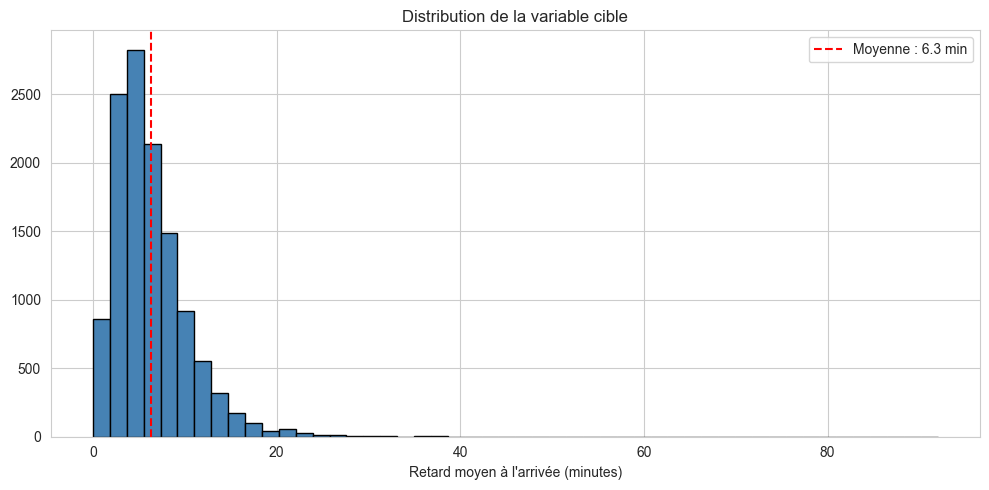

Médiane : 5.4 min | Moyenne : 6.3 min


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean[TARGET].hist(bins=50, ax=ax, color="steelblue", edgecolor="black")
ax.axvline(df_clean[TARGET].mean(), color="red", linestyle="--",
           label=f"Moyenne : {df_clean[TARGET].mean():.1f} min")
ax.set_xlabel("Retard moyen à l'arrivée (minutes)")
ax.set_title("Distribution de la variable cible")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Médiane : {df_clean[TARGET].median():.1f} min | Moyenne : {df_clean[TARGET].mean():.1f} min")


## 6. Saisonnalité — retard par mois et par année

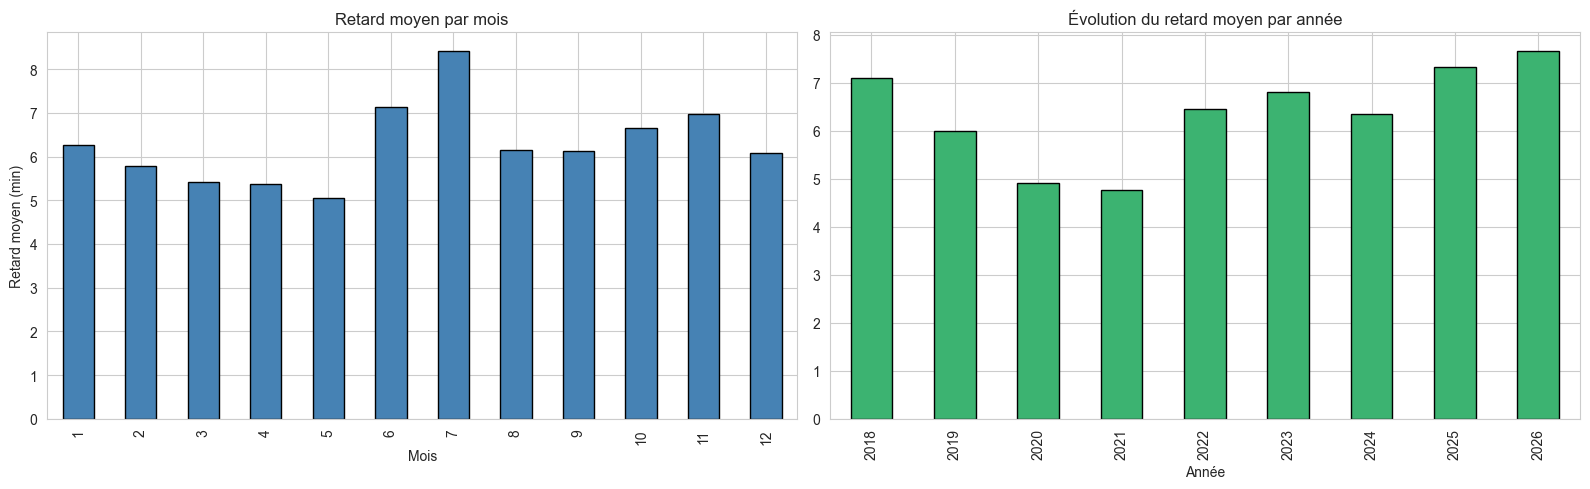

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_clean.groupby("Mois")[TARGET].mean().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Retard moyen (min)")
axes[0].set_title("Retard moyen par mois")

df_clean.groupby("Année")[TARGET].mean().plot(
    kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="black")
axes[1].set_xlabel("Année")
axes[1].set_title("Évolution du retard moyen par année")

plt.tight_layout()
plt.show()


## 7. Top liaisons les plus en retard

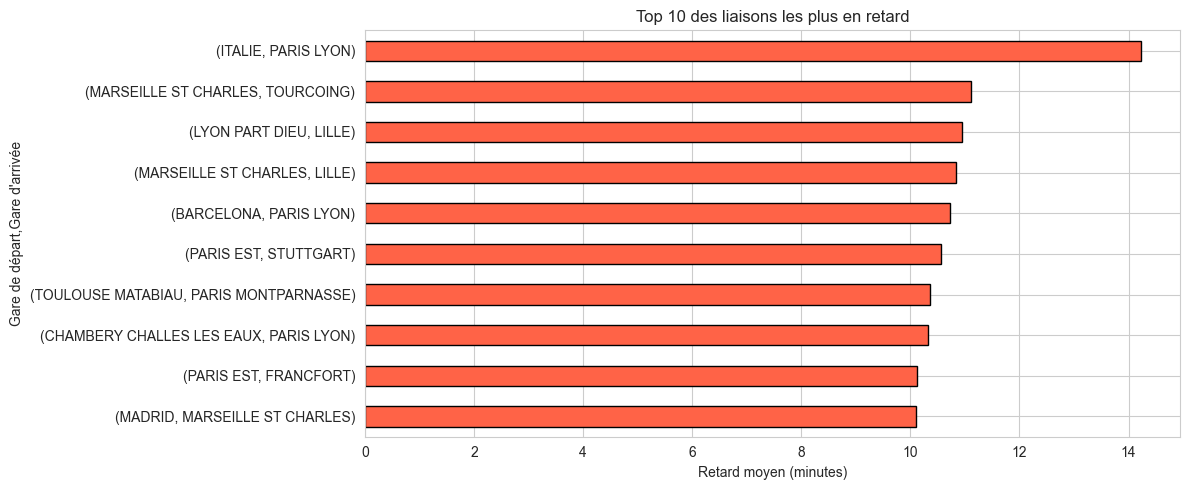

In [11]:
top_liaisons = (
    df_clean.groupby([COL_DEPART, COL_ARRIVEE])[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
top_liaisons.plot(kind="barh", ax=ax, color="tomato", edgecolor="black")
ax.set_xlabel("Retard moyen (minutes)")
ax.set_title("Top 10 des liaisons les plus en retard")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Corrélations avec la variable cible

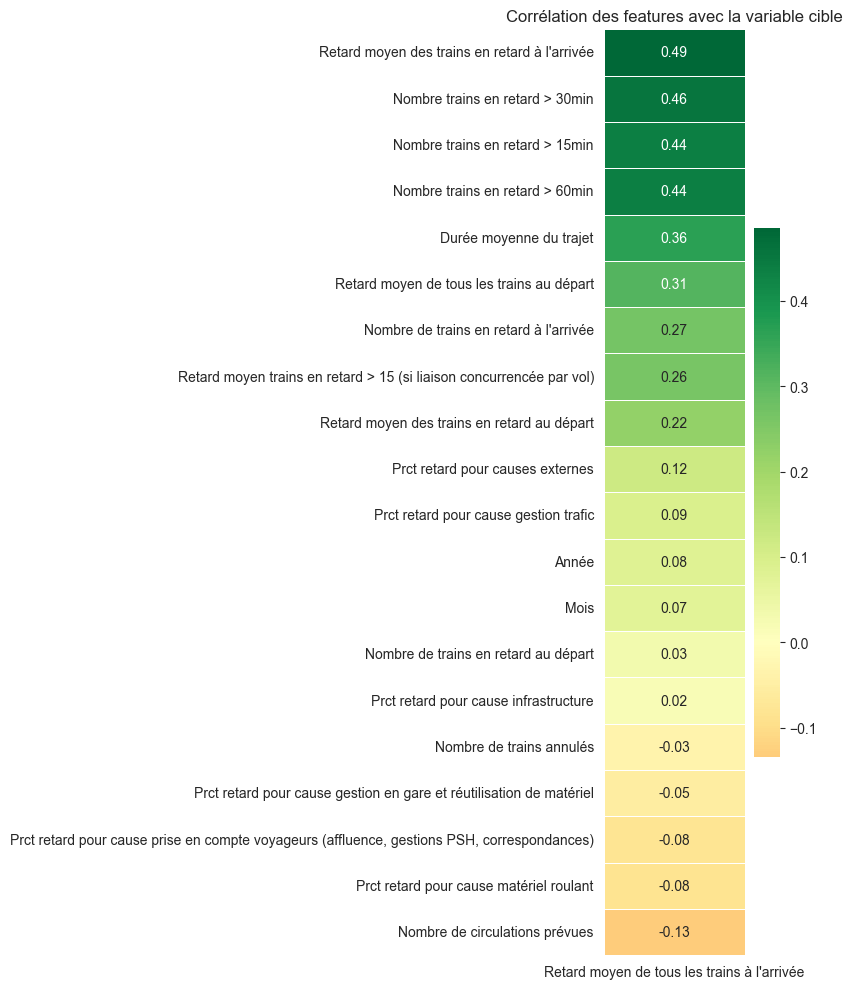

In [12]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
corr = df_clean[numeric_cols].corr()[[TARGET]].drop(TARGET).sort_values(by=TARGET, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Corrélation des features avec la variable cible")
plt.tight_layout()
plt.show()


## Conclusions

- **Saisonnalité** : les mois de juillet et décembre ont les retards les plus élevés (vacances / périodes d'affluence).
- **Tendance** : légère hausse des retards observée sur certaines années — à contextualiser avec les données de grèves.
- **Features corrélées** : le retard moyen au départ, le pourcentage de trains en retard, et les causes externes sont les variables les plus corrélées avec la cible.
- **Outliers** : les retards négatifs (trains en avance) sont filtrés avant la modélisation.